# Risk Analysis: Price/Volatility Acceleration and Jerk

This notebook computes higher-order price dynamics:
- 1st order (velocity): `Returns`
- 2nd order (acceleration): `dReturns/dt`
- 3rd order (jerk): `dAcceleration/dt`
- Volatility velocity: `dSigma/dt` where sigma is rolling return volatility

Smoothing -
- TEMA (Triple Exponential Moving Average)

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [12]:
DATA_DIR = Path.cwd() / 'ohlcv_data_with_features'
if not DATA_DIR.exists():
    DATA_DIR = Path.cwd().parent / 'ohlcv_data_with_features'

csv_files = sorted(DATA_DIR.glob('*.csv'))
if not csv_files:
    raise FileNotFoundError('No CSV files found in ohlcv_data_with_features')

ticker_path = csv_files[0]
df = pd.read_csv(ticker_path)

if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    df = df.sort_values('Date').reset_index(drop=True)

if 'Returns' not in df.columns:
    if 'Close' not in df.columns:
        raise ValueError('Input data must contain either Returns or Close column')
    df['Returns'] = df['Close'].pct_change()

print(f'Loaded: {ticker_path.name}')
print(f'Rows: {len(df):,}')

Loaded: AARTIIND.NS.csv
Rows: 1,250


In [13]:
def tema(series: pd.Series, span: int = 10) -> pd.Series:
    ema1 = series.ewm(span=span, adjust=False).mean()
    ema2 = ema1.ewm(span=span, adjust=False).mean()
    ema3 = ema2.ewm(span=span, adjust=False).mean()
    return (3 * ema1) - (3 * ema2) + ema3


vol_window = 20
tema_span = 10

df['Acceleration'] = df['Returns'].diff()
df['Jerk'] = df['Acceleration'].diff()

df['Sigma'] = df['Returns'].rolling(vol_window).std()
df['Volatility_Velocity'] = df['Sigma'].diff()

df['Acceleration_TEMA'] = tema(df['Acceleration'], span=tema_span)
df['Jerk_TEMA'] = tema(df['Jerk'], span=tema_span)
df['Volatility_Velocity_TEMA'] = tema(df['Volatility_Velocity'], span=tema_span)

display_cols = [
    'Returns',
    'Acceleration', 'Acceleration_TEMA',
    'Jerk', 'Jerk_TEMA',
    'Sigma', 'Volatility_Velocity', 'Volatility_Velocity_TEMA',
]
df[display_cols].tail(10)

,Returns,Acceleration,Acceleration_TEMA,Jerk,Jerk_TEMA,Sigma,Volatility_Velocity,Volatility_Velocity_TEMA
1240,-0.011275,-0.014602,-0.005981,-0.013115,-0.006928,0.016810,-0.001582,-0.000943
1241,0.006305,0.017580,0.003984,0.032182,0.009965,0.016735,-0.000075,-0.000679
1242,0.002266,-0.004039,0.000886,-0.021619,-0.003099,0.016628,-0.000107,-0.000501
1243,-0.019287,-0.021553,-0.009155,-0.017515,-0.010041,0.017294,0.000666,-0.000021
1244,-0.018988,0.000299,-0.005919,0.021852,0.003236,0.017905,0.000611,0.000279
1245,-0.010231,0.008757,0.000191,0.008459,0.006110,0.012882,-0.005023,-0.002071
1246,0.014108,0.024339,0.011353,0.015582,0.011162,0.013254,0.000372,-0.001189
1247,-0.002755,-0.016863,0.000063,-0.041202,-0.011290,0.012955,-0.000299,-0.000878
1248,0.000000,0.002755,0.001274,0.019618,0.001212,0.012802,-0.000153,-0.000591
1249,-0.020442,-0.020442,-0.008418,-0.023197,-0.009692,0.013008,0.000206,-0.000231


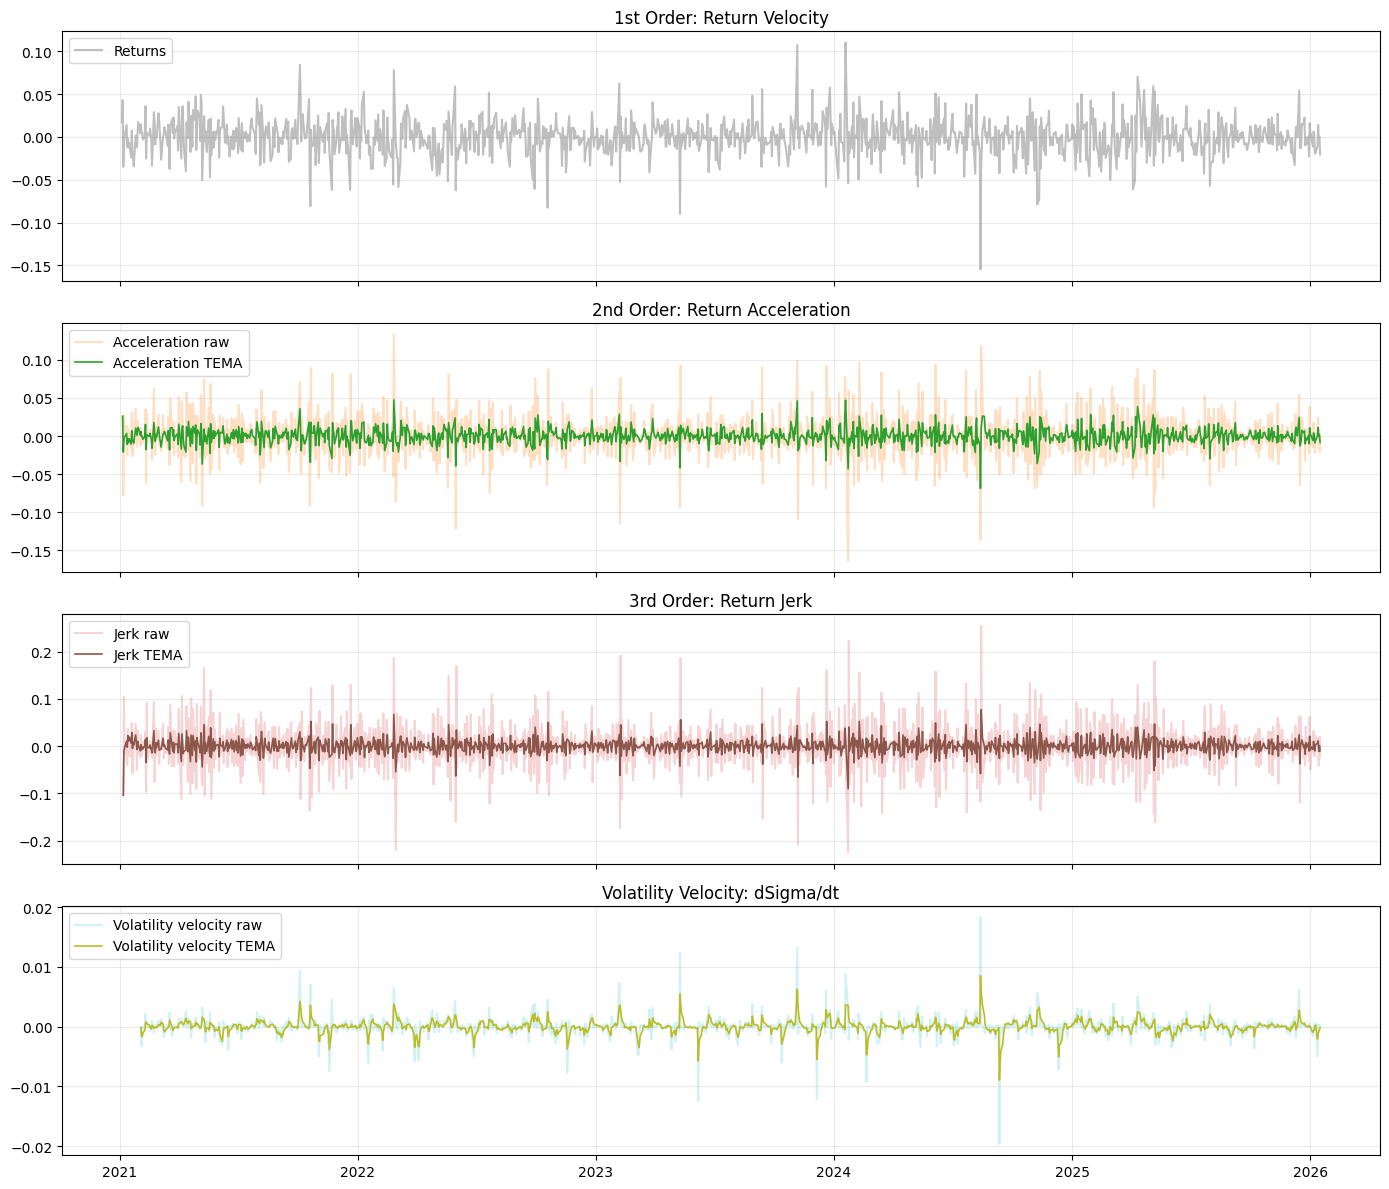

In [14]:
plot_df = df.copy()
if 'Date' in plot_df.columns:
    x = plot_df['Date']
else:
    x = plot_df.index

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

axes[0].plot(x, plot_df['Returns'], color='gray', alpha=0.5, label='Returns')
axes[0].set_title('1st Order: Return Velocity')
axes[0].legend(loc='upper left')

axes[1].plot(x, plot_df['Acceleration'], color='tab:orange', alpha=0.25, label='Acceleration raw')
axes[1].plot(x, plot_df['Acceleration_TEMA'], color='tab:green', linewidth=1.2, label='Acceleration TEMA')
axes[1].set_title('2nd Order: Return Acceleration')
axes[1].legend(loc='upper left')

axes[2].plot(x, plot_df['Jerk'], color='tab:red', alpha=0.2, label='Jerk raw')
axes[2].plot(x, plot_df['Jerk_TEMA'], color='tab:brown', linewidth=1.2, label='Jerk TEMA')
axes[2].set_title('3rd Order: Return Jerk')
axes[2].legend(loc='upper left')

axes[3].plot(x, plot_df['Volatility_Velocity'], color='tab:cyan', alpha=0.2, label='Volatility velocity raw')
axes[3].plot(x, plot_df['Volatility_Velocity_TEMA'], color='tab:olive', linewidth=1.2, label='Volatility velocity TEMA')
axes[3].set_title('Volatility Velocity: dSigma/dt')
axes[3].legend(loc='upper left')

for ax in axes:
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()